
<div style="background-color:#5397cbff;padding:20px;border-radius:10px;">
    <h1 style="color:black; text-align:center;">
        ML Project : F1 lap time prediction
    </h1>
    <h3 style="color:black; text-align:center;">
        Model implementation: Random Forest Regressor
    </h3>
    <h5 style="color:black; text-align:center;">
        Elisabeth Cognet, Nour El Khalili, Chatron Emilie -- MMN2
    </h5>
</div>


# Objective: 
The objective of this notebook is to develop a predictive model capable of estimating the fastest lap for each driver in a given Formula 1 race. Using historical F1 race data, the goal is to understand how driver characteristics, performance, and circuit features influence lap times.


#  Target Variable & Type of Problem:
Our target variable is fastestLapTime : it represents he fastest lap time achieved by each driver in a race, expressed in seconds. 
This is a regression problem, since the target variable(fastest lap time) is continuous.
It falls under supervised learning, as the dataset contains labeled examples representing past fastest lap times recorded by drivers.

We will predict the fastest lap time using 3 kind of algorithms :
- Linear models (more preprocessing) -> Ridge, Lasso
- Tree-based models (less preprocessing) -> RandomForest, XGBoost
- End-to-end model (almost no preprocessing) -> CatBoost

For each model, we will use our two datasets, all data (1996-2024) and recent data (2014-2024).The goal is to evaluate the model using all data and then only data from the post-2014 hybrid era, and to compare their performance. Since the introduction of hybrid power units in 2014 marked a major regulatory and technological shift, the seasons after 2014 represent a more homogeneous and stable era of Formula 1. This analysis will help assess whether limiting the training data to this modern, consistent technical environment improves predictive performance compared to using the full multi-era dataset.

PS: all our train and test datasets are complete (no NaN) so we don't need to take care of this part of the preprocessing

In [2]:
!pip install scikit-optimize
!pip install xgboost
!pip install catboost


   ---------------------------------------- 2/2 [scikit-optimize]

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 1.3/102.4 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 1.8/102.4 MB 3.3 MB/s eta 0:00:31
   - -------------------------------------- 2.9/102.4 MB 3.7 MB/s eta 0:00:28
   - -------------------------------------- 3.7/102.4 MB 3.8 MB/s eta 0:00:27
   - -------------------------------------- 4.5/102.4 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 5.2/102.4 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.3/102.4 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 6.8/102.4 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.6/102.4 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 8.1/102.4 MB 3.8 MB/s eta 0:00:26
   

In [1]:
conda install -c conda-forge catboost


^C

Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.11.0

Please update conda by running

    $ conda update -n base -c defaults conda




3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\cogne\anaconda3

  added / updated specs:
    - catboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.11.12 |       h4c7d964_0         149 KB  conda-forge
    cairo-1.16.0               |       h85cdd14_6         1.9 MB
    catboost-1.2.8             |  py313ha553935_6        48.3 MB  conda-forge
    certifi-2025.11.12         |     pyhd8ed1ab_0         153 KB  conda-forge
    conda-25.7.0               |  py313hfa70ccb_0         1.2 MB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|       h77eed37_0         684 KB  conda-forge
    font-t

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
SKIP_GRID_SEARCH = True # Set to True to skip grid search and use default hyperparameters

#  Some common code and functions for all models:

In [11]:
#all the features we will use for prediction
feature_names = [
    "grid",
    "year",
    "circuitRef",
    "location",
    "trackLength",
    "trackTurns",
    "driverRef",
    "driverNationality",
    "constructorRef",
    "constructorNationality"
]
#we define the categorical and numerical columns here 
#to encode them later depending on the type of model
categorical_cols = [
    "circuitRef",
    "location",
    "driverRef",
    "driverNationality",
    "constructorRef",
    "constructorNationality",
]
numerical_cols = [
    "grid",
    "year",
    "trackLength",
    "trackTurns",
]

## Evaluation functions

In [12]:
#the common function to evaluate a model (compatible with all of our models)
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Train a model, make predictions on the test set,
    and display MAE, RMSE, and R² metrics.

    Parameters:
    - model: an already instantiated sklearn-like model (e.g. RandomForestRegressor())
    - X_train, y_train: training data
    - X_test, y_test: test data
    - model_name: name displayed in the output

    Returns:
    - y_pred: model predictions on X_test
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\nResults for {model_name} :")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    

    return y_pred

In [13]:
#will display agraph with top_n most important features (only for tree-based models)

def plot_feature_importances(model, feature_names, top_n=10):
    """
    Plot the top N feature importances of a fitted tree-based model.

    Parameters:
    - model: trained model with `feature_importances_` attribute 
    - feature_names: list of feature names after preprocessing (one name per column)
    - top_n: number of top features to display (default is 10)
    """

    
    importances = model.feature_importances_
    indices = np.argsort(importances)

    
    top_indices = indices[-top_n:]
    top_features = [feature_names[i] for i in top_indices]
    top_values = importances[top_indices]

    
    plt.figure(figsize=(8, 6))
    plt.barh(top_features, top_values)
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances")
    plt.show()


## Pre-processing pipelines

In [14]:
#pre-processing pipeline basic (only imputation and scaling/encoding)
numeric_transformer_basic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_basic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorial_transformer_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_basic = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_basic, numerical_cols),
        ("cat", categorical_transformer_basic, categorical_cols),
    ],
    remainder="drop"   
)
preprocess_ordinal = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_basic, numerical_cols),
        ("cat", categorial_transformer_ordinal, categorical_cols),
    ],
    remainder="drop"   
)

In [15]:
#same pre-processing as basic but we add feature selection
preprocess_fs = Pipeline(steps=[
    ("columns", preprocess_basic),
    ("feature_selection", SelectKBest(
        score_func=mutual_info_regression,
        k=50   # we can adjust this if needed
    ))
])


# A linear model : Ridge

In [10]:
X_train = pd.read_csv("data/processed/X_train_all.csv")
X_test = pd.read_csv("data/processed/X_test_all.csv")
y_train = pd.read_csv("data/processed/y_train_all.csv")
y_test = pd.read_csv("data/processed/y_test_all.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [99]:
X_train_processed = preprocess_basic.fit_transform(X_train)
X_test_processed = preprocess_basic.transform(X_test)

ridge_model = Ridge(alpha=1.0)
y_pred_ridge = evaluate_model(
    ridge_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    model_name="Ridge Regressor + preprocess basic"
)


Results for Ridge Regressor + preprocess basic :
MAE  : 5.9925
RMSE : 13.9860
R²   : 0.3971


**Analysis of scores**\
These results show that Ridge is able to capture part of the structure in the data, explaining around 40% of the variance in race outcomes. However, the model’s absolute errors remain relatively high: on average, predictions deviate by about 6 seconds, which is significant in the context of Formula 1, where small ranking differences are important.

Because Ridge is a linear model, it cannot learn complex interactions between drivers, teams, circuits, or race dynamics. As a consequence, it underperforms compared to more flexible models such as Random Forest or XGBoost, which better capture non-linear patterns.

# Tree-based models

## RandomForest

### Data 1996-2024

In [100]:
X_train = pd.read_csv('data/processed/X_train_all.csv')
X_test = pd.read_csv('data/processed/X_test_all.csv')
y_train = pd.read_csv('data/processed/y_train_all.csv')
y_test = pd.read_csv('data/processed/y_test_all.csv')

In [101]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()


Results for RandomForest all data + preprocess_basic :
MAE  : 5.3646
RMSE : 13.7221
R²   : 0.4196


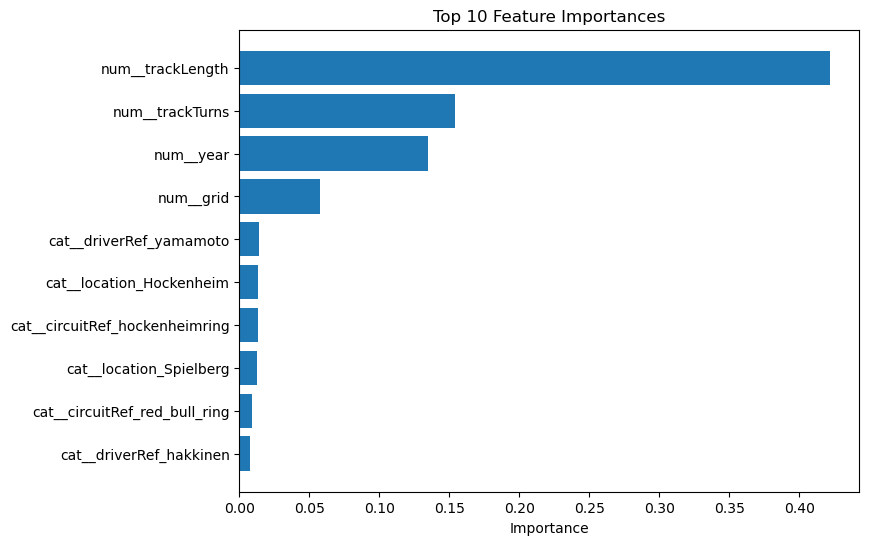

In [102]:
X_train_basic = preprocess_basic.fit_transform(X_train)
X_test_basic  = preprocess_basic.transform(X_test)

#noms des features après preprocess_basic
feature_names_basic = preprocess_basic.get_feature_names_out()

rf_basic = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


y_pred_basic = evaluate_model(
    rf_basic,
    X_train_basic,
    y_train,
    X_test_basic,
    y_test,
    model_name="RandomForest all data + preprocess_basic"
)

plot_feature_importances(
    model=rf_basic,
    feature_names=feature_names_basic,
    top_n=10
)

**Analysis of scores:**

These results indicate that the model explains approximately 42%  of the variance in the fastest lap time, which a strong baseline given the complexity of F1 performance data.
- MAE means that, on average, the model's predictions deviate by about two seconds from the true fastest lap times.
- RMSE is larger because it penalizes larger prediction errors more heavily. A small number of races with very different conditions, like weather, tire degradation, and track surface can likely contribute to these larger errors.
- R^2 suggests the model captures most of the underlying patterns in the data, though further improvement is possible through better feature representation.


**Analysis of feature importance**

The Random Forest model provides a clear and coherent view of the factors that most strongly influence the prediction of fastest lap ties in F1 races. The feature importance raking highlights that track characteristics have the highest explanatory power, followed by temporal effects and competitive context.

1. Track length:
This feature is by far the most influential. Longer circuits naturally produce long lap times, making trackLength a direct determinant of the target variable.

2. Track turns:
The number of corners is also a meaningful predictor. Since circuits with more turns generally lead to slower lap times dude to the reduced straight-line speed and increased braking and acceleration phases. 

3. Year:
The year of the race captures the evolution of Formula 1 technology and regulations over time. Changes in aerodynamics, power units, tire compounds, and safety requirements affect absolute lap times across eras. Therefore the model correctly identifies this long term trend as a source of variation.

4. Grid position:
Although grid position is not directly related to track characteristics, it correlates with underlying performance factors such as car competitiveness and the driver's ability to get the absolute best out of his car. For instance, we know that higher-performing cars (backed up by big teams) typically qualify better and record faster laps (unless it is goat Verstappen, no need for a high performing car). 

5. Circuit-specific and Location specific Variables:
Lastly we have these individual dummy variables derived from categorical encoding that have relatively small but non-negligible impacts. These features capture circuit-specific effects that are not fully represented by length or number of turns, such as altitude, surface type, or layout uniqueness.

### Data 2014-2024

In [103]:
X_train_14 = pd.read_csv("data/processed/X_train_2014.csv")
X_test_14 = pd.read_csv("data/processed/X_test_2014.csv")
y_train_14 = pd.read_csv("data/processed/y_train_2014.csv")
y_test_14 = pd.read_csv("data/processed/y_test_2014.csv")

#convert y to a 1D series
y_train_14 = y_train_14.squeeze()
y_test_14 = y_test_14.squeeze()

X_train_14.shape, X_test_14.shape, y_train_14.shape, y_test_14.shape


((3592, 10), (895, 10), (3592,), (895,))


Results for RandomForest 2014 + preprocess_basic :
MAE  : 3.2067
RMSE : 5.4207
R²   : 0.7414


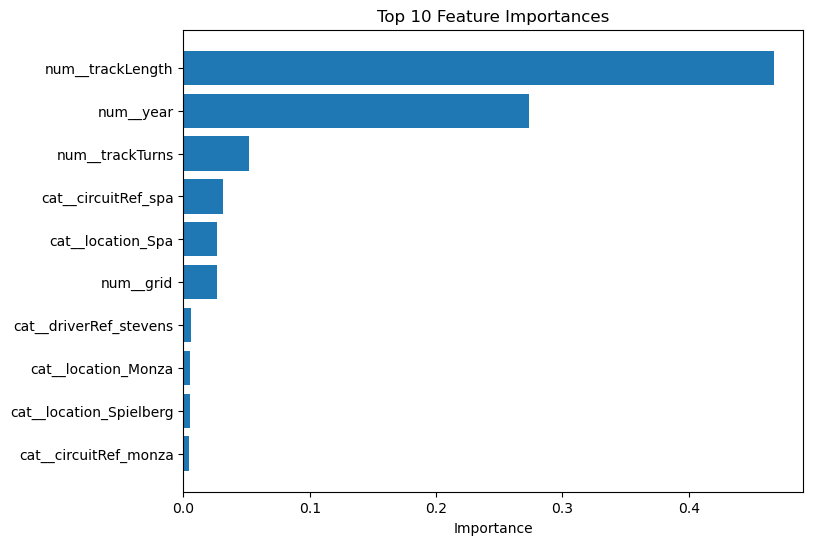

In [104]:
X_train_14_basic = preprocess_basic.fit_transform(X_train_14)
X_test_14_basic  = preprocess_basic.transform(X_test_14)

#noms des features après preprocess_basic
feature_names_basic = preprocess_basic.get_feature_names_out()

rf_basic = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


y_pred_basic = evaluate_model(
    rf_basic,
    X_train_14_basic,
    y_train_14,
    X_test_14_basic,
    y_test_14,
    model_name="RandomForest 2014 + preprocess_basic"
)

plot_feature_importances(
    model=rf_basic,
    feature_names=feature_names_basic,
    top_n=10
)

**Analysis of important features:**

The feature importance results for the model trained on data from 2014 onward clearly highlight the dominance of track characteristics and temporal progression in determining fastest lap times. Compared with the full historical dataset, the post-2014 shows that the contributing variables did not change a lot.

1. Track Length
Same as previous analysis

2. Year
The year variable is the second-most important feature. Even within the hybrid era, gradual advancements in aerodynamics, power unit efficiency, and chassis development continue to influence lap times over time.

3. Track Turns
Same as previous analysis

4. Circuit and Location of SPA 
There is some specifications to Spa circuit like some specific turns layout (Blanchoimont...), asphalt type or just unstable weather that is likely to give a lot of information since it explains more our target variable than our numerical variable 'grid'.

5. Grid Position
Same as previous analysis



**We can observe that R^2 increased from 42 to 74% by keeping the same percentage of test. So we will keep our dataset 2014-2024 for the rest of the notebook.**

Now, we will try doing some fine tuning for RandomForest model. By trying OrdinalEncoder instead of OneHotEncoder and then by optimizing hyperparameters.


Results for RandomForest 2014 + preprocess_ordinal :
MAE  : 3.4184
RMSE : 5.6265
R²   : 0.7214


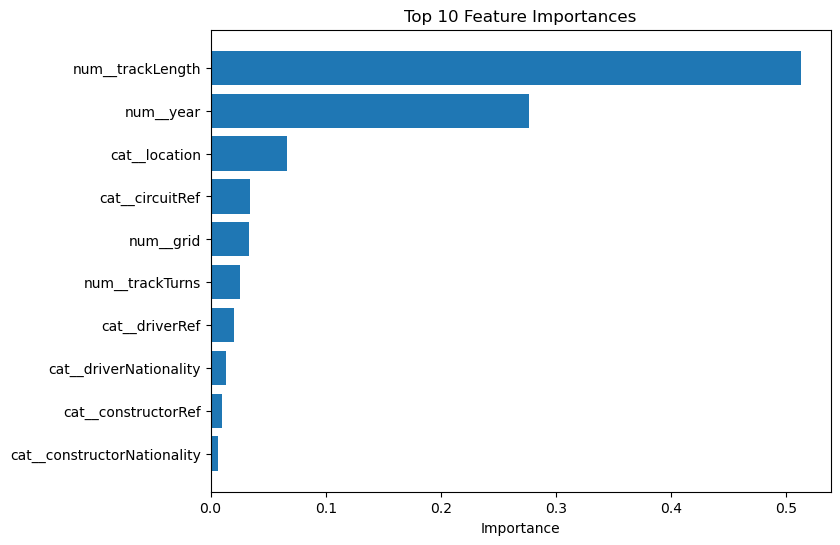

In [105]:
X_train_14_ordinal = preprocess_ordinal.fit_transform(X_train_14)
X_test_14_ordinal  = preprocess_ordinal.transform(X_test_14)

#noms des features après preprocess_basic
feature_names_ordinal = preprocess_ordinal.get_feature_names_out()

rf_basic = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


y_pred_ordinal = evaluate_model(
    rf_basic,
    X_train_14_ordinal,
    y_train_14,
    X_test_14_ordinal,
    y_test_14,
    model_name="RandomForest 2014 + preprocess_ordinal"
)

plot_feature_importances(
    model=rf_basic,
    feature_names=feature_names_ordinal,
    top_n=10
)

| Model                               | MAE    | RMSE   | R²     |
|-------------------------------------|--------|--------|--------|
| **RandomForest + preprocess_basic** | 3.2067 | 5.4207 | 0.7414 |
| **RandomForest + preprocess_ordinal** | 3.4184 | 5.6265 | 0.7214 |
 
The model using **OneHotEncoder (preprocess_basic)** performs better on all metrics:
- Lower MAE : smaller average error  
- Lower RMSE : fewer large errors  
- Higher R² : better explanatory power  

He captures better the specific effects of circuits, teams and pilots in our modern dataset.


### Model fine tuning

In [106]:
if not SKIP_GRID_SEARCH:
    X_train_pre = preprocess_basic.fit_transform(X_train_14)
    X_test_pre  = preprocess_basic.transform(X_test_14)

    #hyperparameters grid
    param_grid = {
        "n_estimators": [300, 500], #number of trees : more trees usually improve performance but increase computation time
        "max_depth": [None, 20, 30], #complexity control : deeper trees can capture more patterns but may overfit
        "min_samples_split": [2, 5], #minimum samples to split a node : higher values prevent overfitting
        "min_samples_leaf": [1, 2], #minimum samples per leaf : higher values prevent overfitting
        "max_features": ["sqrt", 0.5] #number of features to consider at each split : controls diversity among trees
    }

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )
    tscv = TimeSeriesSplit(n_splits=3) #time series cross validation, else it's random and we don't want this for our regression problem
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error", #we want to minimize RMSE because it's direclty interpretable in seconds 
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train_pre, y_train_14)

    print("Best parameters:")
    print(grid_search.best_params_)

    print("\nBest CV RMSE:", -grid_search.best_score_)

In [107]:
if not SKIP_GRID_SEARCH:
    best_rf = grid_search.best_estimator_

    y_pred_gs = evaluate_model(
        best_rf,
        X_train_pre,
        y_train_14,
        X_test_pre,
        y_test_14,
        model_name="RandomForest Tuned (GridSearch + preprocess_basic)"
    )


We have lower metrics with grid search because it regularize and enhance robustness so I want to try another parameters optimization method.

In [108]:
if not SKIP_GRID_SEARCH:
    X_train_pre = preprocess_basic.fit_transform(X_train_14)
    X_test_pre  = preprocess_basic.transform(X_test_14)


    search_spaces = {
        "n_estimators": Integer(300, 500),       
        "max_depth": Integer(20, 30),           
        "min_samples_split": Integer(2, 5),     
        "min_samples_leaf": Integer(1, 2),      
        "max_features": Categorical(["sqrt", 0.5])
    }

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    tscv = TimeSeriesSplit(n_splits=3)  

    opt = BayesSearchCV(
        estimator=rf,
        search_spaces=search_spaces,
        n_iter=30,  
        scoring="neg_root_mean_squared_error",  
        cv=tscv,
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    opt.fit(X_train_pre, y_train_14)

    print("Best parameters (Bayesian Optimization):")
    print(opt.best_params_)

    print("\nBest CV RMSE:", -opt.best_score_)

In [109]:
if not SKIP_GRID_SEARCH:
    best_rf_bayes = opt.best_estimator_

    y_pred_bayes = evaluate_model(
        best_rf_bayes,
        X_train_pre,
        y_train_14,
        X_test_pre,
        y_test_14,
        model_name="RandomForest Tuned (BayesSearch + preprocess_basic)"
    )


Bayes allow us to have better results than GridSearch but we" have the same problem. This cross-valisation optimize the CV RMSE and not the final RMSE. This leads to a more robust but less precise model.

**Conclusion for RandomForest**
This study demonstrates that the predictive modeling of Formula 1 fastest lap times is strongly influenced by the temporal scope and technical context of the dataset. Using a Random Forest Regressor, two models were trained and compared: one using the complete historical dataset, and one using only post-2014 hybrid-era data.

Overall, the results indicate that narrowing the temporal scope to a technical era improves predictive performance, while training on multiple eras introduces variability that reduces model stability. For performance modeling in Formula 1, especially when predicting or understanding lap-time behavior, it is advantageous to analyze data within clearly defined regulatory periods rather than across heterogeneous historical spans.

Then, we saw that between Ordinal and OneHot encoders, the most suitable for our model was OneHotEncoder.

When I tried GridSearch with cross-validation. The results were a little lower but it's only because the tested hyperparameters introduce excessive regularization. Additionally, using strict time-series validation mechanically increases the estimated error.
Here's a summary of our results with different experiments on RandomForest :


| Model                                      | Dataset Years | MAE    | RMSE    | R²     |
|--------------------------------------------|---------------|--------|---------|--------|
| **RandomForest + preprocess_basic**        | 2014–2024     | 3.2067 | 5.4207  | 0.7414 |
| **RandomForest + preprocess_ordinal**      | 2014–2024     | 3.4184 | 5.6265  | 0.7214 |
| **RandomForest Tuned (GridSearch)**        | 2014–2024     | 3.5318 | 5.9577  | 0.6876 |
| **RandomForest + preprocess_basic**        | 1996–2024     | 5.3646 | 13.7221 | 0.4196 |

**Conclusion:**  
The best performance is obtained using **RandomForest + preprocess_basic (2014–2024)** with an RMSE of **5.42s**.  



## XG Boost

In [114]:
xgb_baseline = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


Results for XGBoost baseline (preprocess_basic) :
MAE  : 3.2865
RMSE : 5.4241
R²   : 0.7411


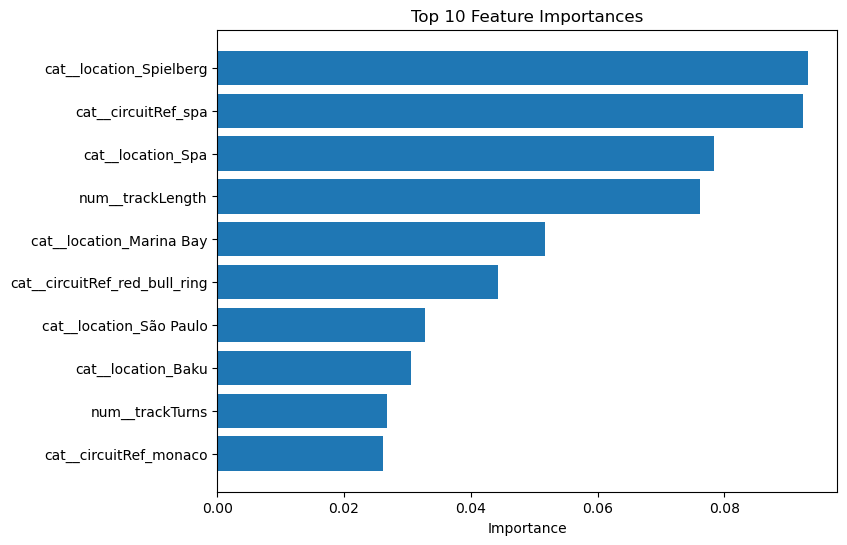

In [116]:
y_pred_xg= evaluate_model(
    xgb_baseline,
    X_train_pre,
    y_train_14,
    X_test_pre,
    y_test_14,
    model_name="XGBoost baseline (preprocess_basic)"
)

plot_feature_importances(
    model=xgb_baseline,
    feature_names=feature_names_basic,
    top_n=10
)

In [118]:
X_train_pre = preprocess_basic.fit_transform(X_train_14)
X_test_pre  = preprocess_basic.transform(X_test_14)

search_spaces_xgb = {
    "n_estimators": Integer(300, 900),          # tree number
    "max_depth": Integer(3, 10),              
    "learning_rate": Real(0.01, 0.15, prior="log-uniform"),  # step size
    "subsample": Real(0.6, 1.0),               
    "colsample_bytree": Real(0.6, 1.0),        
    "min_child_weight": Integer(1, 10),        
    "gamma": Real(0.0, 0.5),                   
    "reg_lambda": Real(1e-2, 10.0, prior="log-uniform"),  
    "reg_alpha": Real(1e-3, 1.0, prior="log-uniform"),    
}

tscv = TimeSeriesSplit(n_splits=3)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

opt_xgb = BayesSearchCV(
    estimator=xgb_base,
    search_spaces=search_spaces_xgb,
    n_iter=40,  # tu peux monter à 60 si tu as le temps
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

opt_xgb.fit(X_train_pre, y_train_14)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

BayesSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=Non...
                             'min_child_weight': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=300, high=900, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.01, high=10.0, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')},
              verbose=2)

In [119]:
print("Best params:", opt_xgb.best_params_)
print("Best CV RMSE:", -opt_xgb.best_score_)

best_xgb_bayes = opt_xgb.best_estimator_

y_pred_xgb_bayes = evaluate_model(
    best_xgb_bayes,
    X_train_pre,
    y_train_14,
    X_test_pre,
    y_test_14,
    model_name="XGBoost tuned (Bayes + preprocess_basic)"
)


Best params: OrderedDict({'colsample_bytree': 0.7654831821697815, 'gamma': 0.4725961249781594, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 10, 'n_estimators': 579, 'reg_alpha': 1.0, 'reg_lambda': 0.9645589706971895, 'subsample': 1.0})
Best CV RMSE: 10.78133788096765

Results for XGBoost tuned (Bayes + preprocess_basic) :
MAE  : 3.3899
RMSE : 5.2340
R²   : 0.7589


**Analysis of metrics anf feature importance**   
The XGBoost Regressor provided high accuracy with an $R^2$ of 74%, close to the performance of the Random Forest model on the 2014-2024 data. This performance confirms that the gradient boosting approach is as effective as the random forest method. 
For feature importance, we can see that categorial OneHot features like 'location_Spielberg' or 'circuitRef_spa/location_spa' are more important than 'trackLength' for example, since these circuits are very particular and that for these ones, the length of track is not the most important.

BayesSearchCV fine tuning improved metrics as shown below :
| Model                                      | MAE    | RMSE   | R²     |
|-------------------------------------------|--------|--------|--------|
| **XGBoost baseline (preprocess_basic)**   | 3.2865 | 5.4241 | 0.7411 |
| **XGBoost tuned (Bayes + preprocess_basic)** | 3.3899 | 5.2340 | 0.7589 |

**Conclusion on Tree-based models**  


# End-to-end model : Cat Boost

In [36]:
X_train_14 = pd.read_csv("data/processed/X_train_2014.csv")
X_test_14  = pd.read_csv("data/processed/X_test_2014.csv")
y_train_14 = pd.read_csv("data/processed/y_train_2014.csv").squeeze()
y_test_14  = pd.read_csv("data/processed/y_test_2014.csv").squeeze()

In [42]:
cat_feats = categorical_cols
cb_baseline = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    thread_count=-1
)

cb_baseline.fit(
    X_train_14, y_train_14,
    cat_features=cat_feats,
    eval_set=(X_test_14, y_test_14),
    use_best_model=True
)

# Predict + metrics
y_pred_cb = cb_baseline.predict(X_test_14)
mae = mean_absolute_error(y_test_14, y_pred_cb)
rmse = np.sqrt(mean_squared_error(y_test_14, y_pred_cb))
r2 = r2_score(y_test_14, y_pred_cb)

print("\nCatBoost Baseline results:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

0:	learn: 16.1207507	test: 10.8520407	best: 10.8520407 (0)	total: 29.8ms	remaining: 29.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4.981494045
bestIteration = 47

Shrink model to first 48 iterations.

CatBoost Baseline results:
MAE  : 4.0189
RMSE : 4.9815
R²   : 0.7816
